Rough vol Calibration
---

In [1]:
# Downloading the needed libraries
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import time
from diffrax import *
import pandas as pd
import scipy.signal as signal
import scipy.special as special
from scipy.optimize import minimize
from scipy.optimize import bisect
from scipy.stats import norm
from scipy.stats import multivariate_normal


# Importing the other codes we need
from controls import *
from hybrid_joint import *
from Jackels import impliedVolJaeckelRational
%matplotlib inline


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found

Quadratic rough Heston model - RDE version

$$ \begin{cases}\mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \\ \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t \end{cases} $$

with $\theta$ some function chosen to match the VIX futures? Check this is the same as solving $V$ first and then taking the exponential martingale.

$$S_t =S_0 \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$


In [2]:
class RDE_QuadHeston:
    
    def __init__(self, grid_points, epsilon, M, T, H,S0):
        """
        grid_points: number of points in the simulation grid
        epsilon: time step?
        H: Hurst parameter
        M: number of paths to simulate
        T: time horizon
        """
        self.S0=S0
        self.epsilon = epsilon
        self.grid_points = grid_points
        self.M, self.T, self.H = M, T, H
        # kappa parameter for the Hybrid scheme
        self.kappa = 1
        
        # create the time grid (over the time horizon 1)
        self.times = jnp.arange(0., 1., self.epsilon)
        # every point x in the grid is approximated with the closest lower integer to x*eps
        # needed for the subsampling
        self.every_nth_pt = int(self.grid_points*self.epsilon)
        # smaller time step
        self.solver_epsilon = 0.01*self.epsilon
        # lag (it has to be slightly bigger than the time step)
        self.lag = 1.2*self.epsilon


    def run__init__(self):
        # generating fractional Bm paths and Bm paths via hybrid scheme
        self.fBmpath, self.Bmpath = hybrid_scheme(self.grid_points, self.M, self.T, self.H, self.kappa)

        # Create the Bm controls
        # Subsampling the Bm paths
        self.subsampled_Bmpath = self.Bmpath[:, ::self.every_nth_pt]
        # Interpolating the subsampled Bm paths
        self.bm_interp = LinearInterpolation(self.times, self.subsampled_Bmpath[0,:])
        self.bm_interp = evaluate_and_reshape(self.bm_interp.evaluate)

        # Create the fbm control
        # Subsampling the fBm paths
        self.subsampled_fBmpath = self.fBmpath[:, ::self.every_nth_pt]
        # Interpolating the subsampled fBm paths
        self.fbm_interp = LinearInterpolation(self.times, self.subsampled_fBmpath[0,:])
        self.fbm_interp = evaluate_and_reshape(self.fbm_interp.evaluate)

        # lagged fBm increments
        self.lagged_fbm_control = lagged_control(lambda t: self.fbm_interp(0,t), self.lag)
        # concatenation of lagged fBm and Bm
        self.lead_lag_control = join_controls(self.lagged_fbm_control, self.bm_interp)

    # precomputing FBm and Bm paths
    def precompute_paths(self, nb_montecarlo):
        """
        nb_montecarlo: number of Montecarlo simulations
        """
        self.lagged_fbm_control_vec, self.bm_interp_vec = [], []
        
        for _ in range(nb_montecarlo):
            self.run__init__()
            self.bm_interp_vec.append(self.bm_interp)
            self.lagged_fbm_control_vec.append(self.lagged_fbm_control)

    
    def callPrice_RDE_QuadHeston_MC(self, params, payoff_function, printYN = False):
        """
        params: parameters
        payoff_function: Payoff function for which we want to compute prices under quadRHeston
        """
        self.prices, self.finalS = [], []
        counter = 0
        
        # for-cycle over the trajectories (i.e. for each traj in our MOntecarlo)
        for (bm_interp, lagged_fbm_control) in zip(self.lagged_fbm_control_vec, self.bm_interp_vec):
            # update couter for the for-cycle
            counter += 1
            # compute integral price and expo martingale for the traj
            integral_price, exp_martingale = self.run_paths_RDE_QuadHeston(params, bm_interp, lagged_fbm_control)
            # add the final value of the exponential martingale (i.e. S_T) to the list 
            # where we store all the different values for the different trajectories
            self.finalS.append(exp_martingale[-1])
            # do the same for the pricing function
            self.prices.append(payoff_function(self.finalS[-1]))
            if printYN:
                print(counter, "|", nb_montecarlo, " || ", "Price: ", self.prices[-1], "ST = ", self.finalS[-1])
    
    # drift of the quadratic rough Heston model       
    def drift_qrh_vol(self, t, y, args): 
        """
        t, y, args
        """
        return jnp.array([lam*(theta - y[1])]) 
    
    # volatility/diffusion of the quadratic rough Heston model 
    def diffusion_qrh_vol(self, t, y, args):
        """
        t, y, args    
        """
        return jnp.array([ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c )])
        
    def run_paths_RDE_QuadHeston(self, params, bm_interp, lagged_fbm_control):
        """
        params, bm_interp, lagged_fbm_control 
        """
        a, b, c, theta, lam, eta, = params

        y0 = jnp.array([1])
        saveat = SaveAt(ts = self.times)
        
        terms = MultiTerm(ODETerm(self.drift_qrh_vol), ControlTerm(self.diffusion_qrh_vol, lagged_fbm_control))
        solution_vol = diffeqsolve(terms, Euler(), 0, 1, dt0 = self.solver_epsilon, max_steps=None, y0=y0, saveat=saveat)
        
        Z = LinearInterpolation(self.times, solution_vol.ys[:,0]).evaluate #create the vol process
        
        y0 = jnp.array([0,0])
        
        drift_qrh_price = lambda t, y, args: jnp.array([-(1/2) * ( a * jnp.square(Z(t) - b) + c ), 0])
        diffusion_qrh_price = lambda t, y, args: jnp.array([[jnp.sqrt(a * jnp.square(Z(t) - b) + c)],[1]])
        terms = MultiTerm(ODETerm(drift_qrh_price), ControlTerm(diffusion_qrh_price, bm_interp))
        integral_price = diffeqsolve(terms, Euler(), 0, 1, dt0 = self.epsilon, max_steps=None, y0=y0, saveat=saveat) # note solver has to have size epsilon for this to be Ito
        exp_martingale = S0*jnp.exp(integral_price.ys[:,0])
        
        return integral_price, exp_martingale
    
    
    def callPrices(self, params, strikes):
        self.finalS = []
        counter = 0
        
        for (bm_interp, lagged_fbm_control) in zip(self.lagged_fbm_control_vec, self.bm_interp_vec):
            # update couter for the for-cycle
            counter += 1
            # compute integral price and expo martingale for the traj
            integral_price, exp_martingale = self.run_paths_RDE_QuadHeston(params, bm_interp, lagged_fbm_control)
            # add the final value of the exponential martingale (i.e. S_T) to the list 
            # where we store all the different values for the different trajectories
            self.finalS.append(exp_martingale[-1])
            return [np.mean(np.maximum(self.finalS - K,0)) for K in strikes]

    def implied_vol(self, params, strikes):
        cps = self.callPrices(params, strikes)
        return [impliedVolJaeckelRational(self.S0, K, c, self.T) for (K,c) in zip(strikes, cps)]



## Numerical tests

In [3]:
H, kappa, M,S0 = 0.1, 1, 1,1
grid_points = 1000
T = 1.
# Model parameters
a, b, c, theta, lam, eta, = 1., 0.5, 1., 2., 0.2, 0.4
params = a, b, c, theta, lam, eta

epsilon = 0.01

In [4]:

nbStrikes = 30
grid_points = 300
nbPaths = 30000
grid = np.linspace(0,T,grid_points)

strikes = np.linspace(S0*np.exp(-0.4), S0*np.exp(0.4), nbStrikes)
log_moneyness = np.log(strikes/S0)

### One-path example

In [5]:
nb_montecarlo = 1

rde = RDE_QuadHeston(grid_points, epsilon, M, T, H,S0)
rde.run__init__()

#############################
t0 = time.time()
rde.precompute_paths(nb_montecarlo)
precomp_time = time.time() - t0
print("Brownian path pre-computation time: ", precomp_time)
#############################

#############################
t0 = time.time()
rde.run_paths_RDE_QuadHeston(params, rde.bm_interp_vec[-1], rde.lagged_fbm_control_vec[-1])
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

Brownian path pre-computation time:  0.0006010532379150391
SDE simulation computation time:  0.5768098831176758


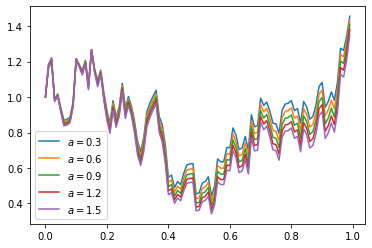

In [6]:
for a in np.linspace(.3, 1.5, 5):
    params = a, b, c, theta, lam, eta
    integral_price, exp_martingale = rde.run_paths_RDE_QuadHeston(params, rde.bm_interp_vec[-1], rde.lagged_fbm_control_vec[-1])
    plt.plot(integral_price.ts[:], exp_martingale[:], label=r'$a=$%.1f' %a)
plt.legend(loc="best")
plt.show()

## Run Monte Carlo computations for option prices

In [7]:
a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,1.2,1.#1., 0.5, 1., 2., 0.2, 0.4
params = a, b, c, theta, lam, eta
nb_montecarlo = 100

In [8]:
#############################
rde = RDE_QuadHeston(grid_points, epsilon, M, T, H,S0)
rde.run__init__()

t0 = time.time()
rde.precompute_paths(nb_montecarlo)
precomp_time = time.time() - t0
print("Brownian path pre-computation time: ", precomp_time)
#############################

Brownian path pre-computation time:  0.05967593193054199


In [ ]:
strike = 2.

#############################
t0 = time.time()
rde.callPrice_RDE_QuadHeston_MC(params, lambda s: np.maximum(s-strike, 0.), printYN = False)
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

In [9]:
Call_prices = rde.callPrices(params, strikes)
dtCalls = time.time() - t0
print("Computation time: ", dtCalls)
print("Prices: ", Call_prices)

Computation time:  3.7165586948394775
Prices:  [np.float64(0.9025831102448783), np.float64(0.8742553636377876), np.float64(0.8459276170306969), np.float64(0.817599870423606), np.float64(0.7892721238165153), np.float64(0.7609443772094246), np.float64(0.7326166306023338), np.float64(0.7042888839952431), np.float64(0.6759611373881524), np.float64(0.6476333907810617), np.float64(0.619305644173971), np.float64(0.5909778975668802), np.float64(0.5626501509597897), np.float64(0.5343224043526988), np.float64(0.505994657745608), np.float64(0.4776669111385172), np.float64(0.44933916453142664), np.float64(0.42101141792433605), np.float64(0.39268367131724524), np.float64(0.36435592471015443), np.float64(0.3360281781030636), np.float64(0.30770043149597304), np.float64(0.27937268488888223), np.float64(0.25104493828179164), np.float64(0.22271719167470083), np.float64(0.19438944506761002), np.float64(0.16606169846051944), np.float64(0.13773395185342863), np.float64(0.10940620524633804), np.float64(0.08

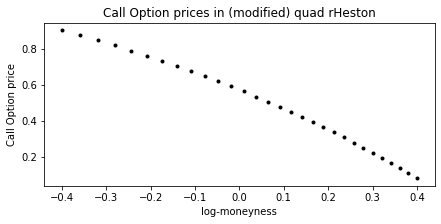

In [10]:
plt.figure(figsize=(7,3))
plt.plot(log_moneyness,Call_prices, 'k.')
#plt.plot(log_moneyness,Call_prices_fixedH, 'b+')
plt.xlabel('log-moneyness')
plt.ylabel('Call Option price')
plt.title('Call Option prices in (modified) quad rHeston')
plt.show()

## Import option price data

In [11]:
r,q = 0.,0.
S0 = 179.83

data = pd.read_csv('dataOptionPrices.csv')
def logstrike(S0,K,T): return np.log(K/S0*np.exp(-(r-q)*T))
data['LogStrike'] = [logstrike(S0,K,T) for K,T in zip(data['Strike'],data['Expiration'])]

data['IV'] = [impliedVolJaeckelRational(S0, K, c, T) for K,T,c in zip(data['Strike'],data['Expiration'],data['midPrice'])]

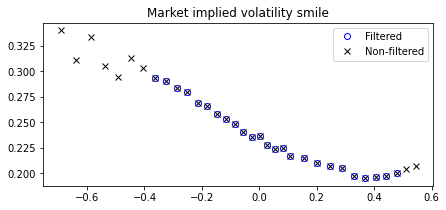

We use the filtered data for calibration only


In [12]:
ListMat = data["Expiration"].unique()
indexMat = -2 ## Select maturity index

df_filt = data[(data["Expiration"] == ListMat[indexMat]) & (data["IV"] >0.) & (data["IV"] <1.) & (data["LogStrike"] < 0.5) & (data["LogStrike"] > -0.4)]
df_nonfilt = data[data["Expiration"] == ListMat[indexMat]]

plt.figure(figsize=(7,3))
plt.plot(df_filt["LogStrike"].values, df_filt["IV"].values, "bo", mfc="None", label="Filtered")
plt.plot(df_nonfilt["LogStrike"].values, df_nonfilt["IV"].values, "kx", mfc="None", label="Non-filtered")
plt.title("Market implied volatility smile")
plt.legend(loc="best")
plt.show()
print("We use the filtered data for calibration only")

In [13]:
ivs_market = df_filt["IV"].values
strikes = df_filt["Strike"].values
T = ListMat[indexMat]

### Calibration on Call prices (fixed H)

In [14]:
def lossFunction_prices_fixedH(params, rde, strikes, dispPrint=False):
    """
    Loss function: we consider the L2 error
    """
    rde = RDE_QuadHeston(grid_points, epsilon, M, T, H, S0)
    rde.run__init__()
    rde.precompute_paths(nb_montecarlo)
    
    callPrices = rde.callPrices(params, strikes)
    normError = np.sum([((a-b)/rde.S0)**2 for (a,b) in zip(callPrices, prices_market)])
    if dispPrint:
        print("L2 error: ", np.round(normError, 5), "| Parameters: ", [np.round(p, 5) for p in params])
    return normError

In [15]:
H, kappa, M = 0.1, 1, 1000
S0 = 179.83
T = 1.

epsilon = 0.01

grid_points = 600
nbPaths = 20000
prices_market = df_filt["midPrice"]
calibBounds_noH = ((0.,1),(0.,1.),(0.0001,0.003),(0.05,0.15),(0.5,1.5),(0.5,1.5))


rde = RDE_QuadHeston(grid_points, epsilon, M, T, H, S0)

In [16]:
nb_init_test = 20
loss_best_init = 1
a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,1.2,1.#1., 0.5, 1., 2., 0.2, 0.4
p_best_init = a, b, c, theta, lam, eta


for i in range(nb_init_test):
    a = np.random.rand()*(calibBounds_noH[0][1] - calibBounds_noH[0][0])  + calibBounds_noH[0][0]
    b = np.random.rand()*(calibBounds_noH[1][1] - calibBounds_noH[1][0])  + calibBounds_noH[1][0]
    c = np.random.rand()*(calibBounds_noH[2][1] - calibBounds_noH[2][0])  + calibBounds_noH[2][0]
    theta = np.random.rand()*(calibBounds_noH[3][1] - calibBounds_noH[3][0])  + calibBounds_noH[3][0]
    lam = 1.2 #np.random.rand()*(calibBounds_noH[4][1] - calibBounds_noH[4][0])  + calibBounds_noH[4][0]
    eta = 1 #np.random.rand()*(calibBounds_noH[5][1] - calibBounds_noH[5][0])  + calibBounds_noH[5][0]
    
    params = a, b, c, theta, lam, eta
    currentLoss = lossFunction_prices_fixedH(params, rde, strikes, dispPrint=True)
    if loss_best_init > currentLoss:
        p_best_init = params
        loss_best_init = currentLoss

print("L2 error: ", np.round(loss_best_init, 5), "| Parameters: ", [np.round(p, 5) for p in p_best_init])
    

L2 error:  0.20287 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.int64(1)]
L2 error:  0.45452 | Parameters:  [np.float64(0.06381), np.float64(0.17817), np.float64(0.00267), np.float64(0.13641), np.float64(1.2), np.int64(1)]
L2 error:  0.28398 | Parameters:  [np.float64(0.3304), np.float64(0.55227), np.float64(0.00271), np.float64(0.14729), np.float64(1.2), np.int64(1)]
L2 error:  1.0527 | Parameters:  [np.float64(0.19953), np.float64(0.26066), np.float64(0.00117), np.float64(0.10214), np.float64(1.2), np.int64(1)]
L2 error:  6.33264 | Parameters:  [np.float64(0.61536), np.float64(0.80497), np.float64(0.00234), np.float64(0.13846), np.float64(1.2), np.int64(1)]
L2 error:  0.60038 | Parameters:  [np.float64(0.04205), np.float64(0.95125), np.float64(0.00288), np.float64(0.06829), np.float64(1.2), np.int64(1)]
L2 error:  0.45642 | Parameters:  [np.float64(0.74766), np.float64(0.57632), np.float64(0.00158), np.float64

In [17]:
print("Optimal stating point:")
loss_best = lossFunction_prices_fixedH(p_best_init, rde, strikes, dispPrint=True)

Optimal stating point:
L2 error:  1.64718 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.int64(1)]


In [18]:
optim = minimize(lossFunction_prices_fixedH, p_best_init, args=(rde, strikes, True), method='L-BFGS-B', bounds=calibBounds_noH, tol=1E-2)
optimal_param_noH = optim.x
print("Calibration completed")

L2 error:  0.56986 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.4763 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.04642 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  5.79043 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.43902 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  3.46561 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.55528 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.flo

L2 error:  0.55396 | Parameters:  [np.float64(0.28132), np.float64(0.86794), np.float64(0.00074), np.float64(0.06244), np.float64(1.19996), np.float64(1.00003)]
L2 error:  0.60038 | Parameters:  [np.float64(0.28132), np.float64(0.86794), np.float64(0.00074), np.float64(0.06244), np.float64(1.19996), np.float64(1.00003)]
L2 error:  1.67439 | Parameters:  [np.float64(0.28132), np.float64(0.86794), np.float64(0.00074), np.float64(0.06244), np.float64(1.19996), np.float64(1.00003)]
L2 error:  0.7893 | Parameters:  [np.float64(0.28129), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.37134 | Parameters:  [np.float64(0.28129), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  79.28032 | Parameters:  [np.float64(0.28129), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.60038 | Parameters:  [np.float64(0.28129), np

L2 error:  0.60038 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  12.01402 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  84.83316 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.5385 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.07108 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.28597 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.float64(0.00074), np.float64(0.06244), np.float64(1.2), np.float64(1.0)]
L2 error:  0.0324 | Parameters:  [np.float64(0.28128), np.float64(0.86793), np.fl

In [19]:
print("Initial parameters: ", [np.round(p, 4) for p in p_best_init])
print("Optimal parameters: ", [np.round(p, 4) for p in optimal_param_noH])

Initial parameters:  [np.float64(0.2813), np.float64(0.8679), np.float64(0.0007), np.float64(0.0624), np.float64(1.2), np.int64(1)]
Optimal parameters:  [np.float64(0.2813), np.float64(0.8679), np.float64(0.0007), np.float64(0.0624), np.float64(1.2), np.float64(1.0)]


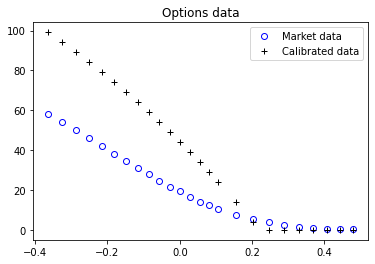

In [25]:

rde = RDE_QuadHeston(grid_points, epsilon, M, T, H,S0)
rde.run__init__()
rde.precompute_paths(1000)
callPrices_noH = rde.callPrices(optimal_param_noH, strikes)

plt.plot(df_filt["LogStrike"], prices_market, 'bo', mfc="None", label="Market data")
plt.plot(df_filt["LogStrike"], callPrices_noH, 'k+', label="Calibrated data")
plt.legend(loc="best")
plt.title("Options data")
plt.show()